24BAD031-Harish M K
PART A: DATASET PREPARATION
1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Tiny Shakespeare dataset downloaded successfully!

First 500 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor

Total number of characters: 1115394

Lowercase text:
first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


PART B COMPLETED SUCCESSFULLY!


PART C: COMPARISON OF OPTIMIZATION ALGORITHMS

Training using Adam Optimizer
--------------------------------------------------
Epoch 1/3
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.0512 - loss: 6.5681 - val_accuracy: 0.0749 - val_loss: 6.3679
Epoch 2/3
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.0887 - loss: 5.9410 - val_accuracy: 0.0821 - val_loss: 6.2795
Epoch 3/3
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1019 - loss: 5.6302 - val_accuracy: 0.0837 - val_loss: 6.2980

Adam Results:
Training Loss       : 5.381
Training Accuracy   : 0.1144
Validation Loss     : 6.298
Validation Accuracy : 0.0837

Training using RMSprop Optimizer
--------------------------------------------------
Epoch 1/3
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.0356 - loss: 6.7942 - val_accuracy: 0.0522 - val_loss: 6.5621
Epoch 2/3
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.0650 - loss: 6.4075 - val_accuracy: 0.0

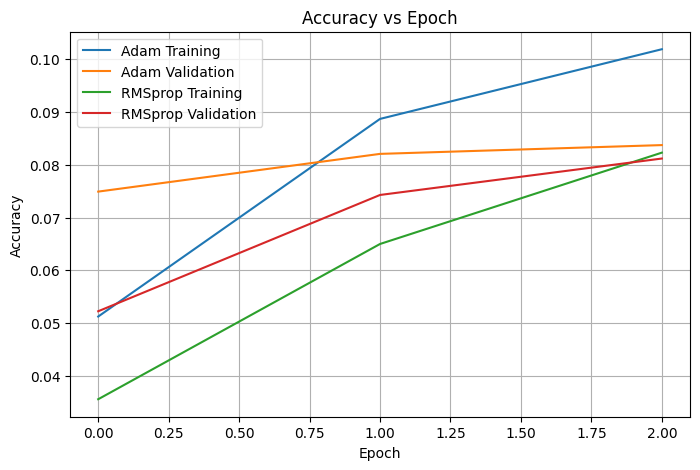

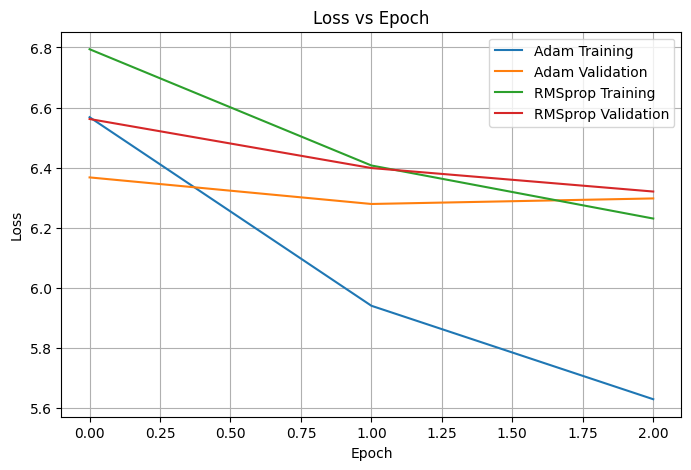


PART C COMPLETED SUCCESSFULLY!


PART D: TEXT GENERATION

Selected Optimizer: Adam

Generated Text 1
--------------------------------------------------
to be or not to be a <OOV> of the world and the <OOV> of the world and <OOV> the <OOV> of the world and <OOV> the <OOV> of the world and <OOV> the <OOV> of

Generated Text 2
--------------------------------------------------
the king and all the crown and in the world and the <OOV> of the world and <OOV> the <OOV> of the world and <OOV> the <OOV> of the world and <OOV>

Generated Text 3
--------------------------------------------------
my lord and i have heard the king and <OOV> the crown and the <OOV> of the world and <OOV> the <OOV> of the world and <OOV> the <OOV> of the world

Generated Text 4
--------------------------------------------------
what is the king and <OOV> the <OOV> of the world and the <OOV> of the world and <OOV> the <OOV> of the world and <OOV> the <OOV> of the world and <OOV>


OBSERVATION

The RNN model generate

In [1]:
print("24BAD031-Harish M K")

# IMPORT LIBRARIES
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# SET RANDOM SEED
np.random.seed(42)
tf.random.set_seed(42)

# PART A: DATASET PREPARATION
print("=" * 60)
print("PART A: DATASET PREPARATION")
print("=" * 60)

# 1. Download Tiny Shakespeare Dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
path = tf.keras.utils.get_file("tinyshakespeare.txt", origin=url)
print("\nTiny Shakespeare dataset downloaded successfully!")

# 2. Read Dataset
with open(path, "r", encoding="utf-8") as file:
    text = file.read()
print("\nFirst 500 characters:")
print(text[:500])
print("\nTotal number of characters:", len(text))

# 3. Convert Text to Lowercase
text = text.lower()
print("\nLowercase text:")
print(text[:300])

# 4. Tokenization
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts([text])
word_sequences = tokenizer.texts_to_sequences([text])[0]
print("\nTotal number of tokens:", len(word_sequences))

# 5. Create Vocabulary
word_index = tokenizer.word_index
vocab_size = min(10000, len(word_index) + 1)
print("Vocabulary size:", vocab_size)
print("\nFirst 20 words in vocabulary:")
for word, index in list(word_index.items())[:20]:
    print(word, ":", index)

# 6. Generate Input Sequences
sequence_length = 20
input_sequences = []
for i in range(sequence_length, len(word_sequences)):
    sequence = word_sequences[i-sequence_length:i+1]
    input_sequences.append(sequence)
input_sequences = np.array(input_sequences)
print("\nTotal input sequences:", len(input_sequences))
print("Input sequence shape:", input_sequences.shape)

# 7. Separate Input and Target
X = input_sequences[:, :-1]
y = input_sequences[:, -1]
print("\nX shape:", X.shape)
print("y shape:", y.shape)

# 8. Train-Validation Split
split = int(0.9 * len(X))
X_train = X[:split]
y_train = y[:split]
X_val = X[split:]
y_val = y[split:]
print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_val))

# 9. Padding
X_train = pad_sequences(X_train, maxlen=sequence_length, padding="pre")
X_val = pad_sequences(X_val, maxlen=sequence_length, padding="pre")
print("\nFinal Training Shape:", X_train.shape)
print("Final Validation Shape:", X_val.shape)
print("\nPART A COMPLETED SUCCESSFULLY!")

# PART B: IMPLEMENTING THE RNN MODEL
print("\n")
print("=" * 60)
print("PART B: IMPLEMENTING RNN MODEL")
print("=" * 60)

# Create RNN Model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128),
    SimpleRNN(128),
    Dense(vocab_size, activation="softmax")
])

# Compile Model
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Display Model Architecture
print("\nRNN MODEL SUMMARY:\n")
model.summary()
print("\nPART B COMPLETED SUCCESSFULLY!")

# PART C: COMPARISON OF OPTIMIZATION ALGORITHMS
print("\n")
print("=" * 60)
print("PART C: COMPARISON OF OPTIMIZATION ALGORITHMS")
print("=" * 60)

# Create Model Function
def create_model():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=128),
        SimpleRNN(128),
        Dense(vocab_size, activation="softmax")
    ])
    return model

epochs = 3
batch_size = 128

# ADAM OPTIMIZER
print("\nTraining using Adam Optimizer")
print("-" * 50)
adam_model = create_model()
adam_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
adam_history = adam_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size, verbose=1)

adam_train_loss, adam_train_accuracy = adam_model.evaluate(X_train, y_train, verbose=0)
adam_val_loss, adam_val_accuracy = adam_model.evaluate(X_val, y_val, verbose=0)

print("\nAdam Results:")
print("Training Loss       :", round(adam_train_loss, 4))
print("Training Accuracy   :", round(adam_train_accuracy, 4))
print("Validation Loss     :", round(adam_val_loss, 4))
print("Validation Accuracy :", round(adam_val_accuracy, 4))

# RMSPROP OPTIMIZER
print("\nTraining using RMSprop Optimizer")
print("-" * 50)
rms_model = create_model()
rms_model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
rms_history = rms_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size, verbose=1)

rms_train_loss, rms_train_accuracy = rms_model.evaluate(X_train, y_train, verbose=0)
rms_val_loss, rms_val_accuracy = rms_model.evaluate(X_val, y_val, verbose=0)

print("\nRMSprop Results:")
print("Training Loss       :", round(rms_train_loss, 4))
print("Training Accuracy   :", round(rms_train_accuracy, 4))
print("Validation Loss     :", round(rms_val_loss, 4))
print("Validation Accuracy :", round(rms_val_accuracy, 4))

# OPTIMIZER COMPARISON
print("\n")
print("=" * 60)
print("OPTIMIZER COMPARISON")
print("=" * 60)
print(f"{'Metric':<25}{'Adam':<15}{'RMSprop':<15}")
print("-" * 55)
print(f"{'Training Accuracy':<25}{adam_train_accuracy:<15.4f}{rms_train_accuracy:<15.4f}")
print(f"{'Validation Accuracy':<25}{adam_val_accuracy:<15.4f}{rms_val_accuracy:<15.4f}")
print(f"{'Training Loss':<25}{adam_train_loss:<15.4f}{rms_train_loss:<15.4f}")
print(f"{'Validation Loss':<25}{adam_val_loss:<15.4f}{rms_val_loss:<15.4f}")

# ACCURACY GRAPH
plt.figure(figsize=(8, 5))
plt.plot(adam_history.history["accuracy"], label="Adam Training")
plt.plot(adam_history.history["val_accuracy"], label="Adam Validation")
plt.plot(rms_history.history["accuracy"], label="RMSprop Training")
plt.plot(rms_history.history["val_accuracy"], label="RMSprop Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid()
plt.show()

# LOSS GRAPH
plt.figure(figsize=(8, 5))
plt.plot(adam_history.history["loss"], label="Adam Training")
plt.plot(adam_history.history["val_loss"], label="Adam Validation")
plt.plot(rms_history.history["loss"], label="RMSprop Training")
plt.plot(rms_history.history["val_loss"], label="RMSprop Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid()
plt.show()

print("\nPART C COMPLETED SUCCESSFULLY!")

# PART D: TEXT GENERATION
print("\n")
print("=" * 60)
print("PART D: TEXT GENERATION")
print("=" * 60)

# Select Best Model
if adam_val_accuracy >= rms_val_accuracy:
    final_model = adam_model
    best_optimizer = "Adam"
else:
    final_model = rms_model
    best_optimizer = "RMSprop"

print("\nSelected Optimizer:", best_optimizer)

# Create Reverse Word Index
reverse_word_index = {index: word for word, index in tokenizer.word_index.items()}

# Text Generation Function
def generate_text(seed_text, next_words=30):
    result = seed_text.lower()
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = token_list[-sequence_length:]
        token_list = pad_sequences([token_list], maxlen=sequence_length, padding="pre")
        prediction = final_model.predict(token_list, verbose=0)[0]
        predicted_id = np.argmax(prediction)
        predicted_word = reverse_word_index.get(predicted_id, "")
        if predicted_word == "":
            break
        result += " " + predicted_word
    return result

# SAMPLE 1
seed1 = "to be or not to be"
print("\nGenerated Text 1")
print("-" * 50)
print(generate_text(seed1, next_words=30))

# SAMPLE 2
seed2 = "the king"
print("\nGenerated Text 2")
print("-" * 50)
print(generate_text(seed2, next_words=30))

# SAMPLE 3
seed3 = "my lord"
print("\nGenerated Text 3")
print("-" * 50)
print(generate_text(seed3, next_words=30))

# SAMPLE 4
seed4 = "what is the"
print("\nGenerated Text 4")
print("-" * 50)
print(generate_text(seed4, next_words=30))

# OBSERVATION
print("\n")
print("=" * 60)
print("OBSERVATION")
print("=" * 60)
print("""
The RNN model generated text using different seed sentences.
The generated text contains words and patterns learned from the
Tiny Shakespeare dataset. Some generated sentences are meaningful,
while some are not completely coherent. This is because a Simple
RNN has difficulty learning long-term dependencies in text.

The model was able to learn sequential patterns and predict the
next word based on previously given words. Adam and RMSprop were
compared, and the model with better validation accuracy was selected
for text generation.
""")

# EXPERIMENT COMPLETED
print("=" * 60)
print("EXPERIMENT COMPLETED SUCCESSFULLY!")
print("=" * 60)

In [2]:
model.build((None, sequence_length))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10000)          │     1,290,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,602,896 (9.93 MB)

 Trainable params: 2,602,896 (9.93 MB)

 Non-trainable params: 0 (0.00 B)